# COMP4318/5318 Assignment 2: Image Classification

### Group number: 136  , SID1: 541006514 , SID2: ..., SID3: ..., SID4: ... 

This notebook implements an image classification pipeline for the PathMNIST dataset. The workflow includes data loading, exploration, preprocessing, implementation of three classifiers, hyperparameter tuning, final model evaluation, and AI acknowledgement.

The three classifiers are:

1. An algorithm of choice from the first six weeks of the course
2. A fully connected neural network / multilayer perceptron (MLP)
3. A convolutional neural network (CNN)

## Setup and dependencies
This section imports the main libraries required for the image classification pipeline. NumPy is used for array handling, pandas is used for tabular summaries, matplotlib is used for visualisation, and scikit-learn is used for preprocessing, baseline modelling, and evaluation. TensorFlow/Keras is imported for the MLP and CNN models later in the notebook.

A fixed random seed is also set to improve reproducibility across notebook runs.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# TensorFlow / Keras for MLP and CNN models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
NumPy version: 2.4.4
TensorFlow version: 2.21.0


## 1. Data loading, exploration, and preprocessing


This section loads the PathMNIST image classification dataset and explores its basic structure. The exploration checks the number of training and test samples, image dimensions, label format, class distribution, example images, and pixel intensity ranges.

This is used to decide suitable preprocessing steps before training the baseline machine learning model, MLP, and CNN.

In [2]:
# Define dataset folder path
DATA_DIR = Path("Assignment2Data")

X_train_path = DATA_DIR / "X_train.npy"
X_test_path = DATA_DIR / "X_test.npy"
y_train_path = DATA_DIR / "y_train.npy"
y_test_path = DATA_DIR / "y_test.npy"

# Check whether all required files exist
required_files = [X_train_path, X_test_path, y_train_path, y_test_path]

for file_path in required_files:
    print(file_path, "exists:", file_path.exists())

# Load the dataset
X_train = np.load(X_train_path)
X_test = np.load(X_test_path)
y_train = np.load(y_train_path)
y_test = np.load(y_test_path)

print("\nDataset loaded successfully.")

Assignment2Data/X_train.npy exists: True
Assignment2Data/X_test.npy exists: True
Assignment2Data/y_train.npy exists: True
Assignment2Data/y_test.npy exists: True

Dataset loaded successfully.


## Inspecting dataset structure

This step checks the shape, data type, and label structure of the loaded arrays. This confirms the number of training and test samples, image dimensions, number of colour channels, and label format before preprocessing.

In [3]:
# Inspect dataset shapes and data types
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nX_train data type:", X_train.dtype)
print("X_test data type:", X_test.dtype)
print("y_train data type:", y_train.dtype)
print("y_test data type:", y_test.dtype)

print("\nFirst 10 training labels:")
print(y_train[:10])

X_train shape: (32000, 28, 28, 3)
X_test shape: (8000, 28, 28, 3)
y_train shape: (32000,)
y_test shape: (8000,)

X_train data type: uint8
X_test data type: uint8
y_train data type: uint8
y_test data type: uint8

First 10 training labels:
[7 3 4 2 6 2 0 7 5 5]


### Class distribution

This step checks the number of unique classes and the number of images in each class. Class distribution is important because strong imbalance can affect model training, evaluation, and interpretation of performance.

Number of classes: 9


,Class label,Training samples
0,0,3490
1,1,3431
2,2,3505
3,3,3656
4,4,2950
5,5,4290
6,6,2728
7,7,3253
8,8,4697


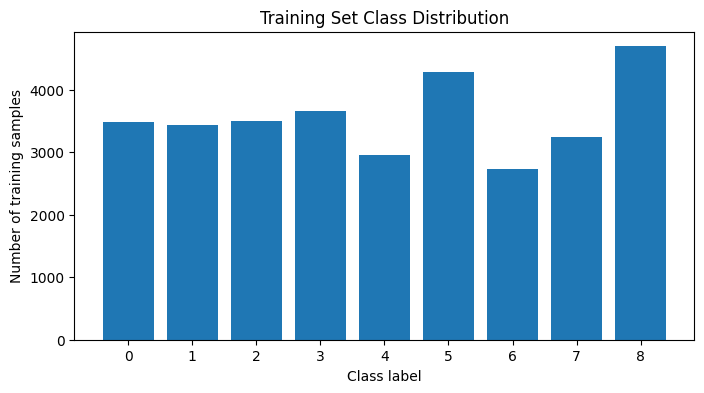

In [4]:
# Check unique class labels and their counts
class_labels, class_counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Class label": class_labels,
    "Training samples": class_counts
})

print("Number of classes:", len(class_labels))
display(class_distribution)

# Plot class distribution
plt.figure(figsize=(8, 4))
plt.bar(class_distribution["Class label"], class_distribution["Training samples"])
plt.xlabel("Class label")
plt.ylabel("Number of training samples")
plt.title("Training Set Class Distribution")
plt.xticks(class_labels)
plt.show()

### Pixel intensity exploration

This step examines the range of pixel values in the image arrays. Since the images are stored using integer pixel values, checking the minimum and maximum values helps determine whether normalisation is required before training the models.

In [5]:
# Check pixel value ranges
print("Training image pixel range:")
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

print("\nTest image pixel range:")
print("Minimum pixel value:", X_test.min())
print("Maximum pixel value:", X_test.max())

print("\nMean pixel value in training set:", X_train.mean())
print("Standard deviation of pixel values in training set:", X_train.std())

Training image pixel range:
Minimum pixel value: 0
Maximum pixel value: 255

Test image pixel range:
Minimum pixel value: 0
Maximum pixel value: 255

Mean pixel value in training set: 168.21381580835458
Standard deviation of pixel values in training set: 43.716173130208134


### Sample images from each class

This step displays example training images from each class. Visual inspection helps identify the type of image data, the colour structure, and whether classes may be visually similar or difficult to separate.

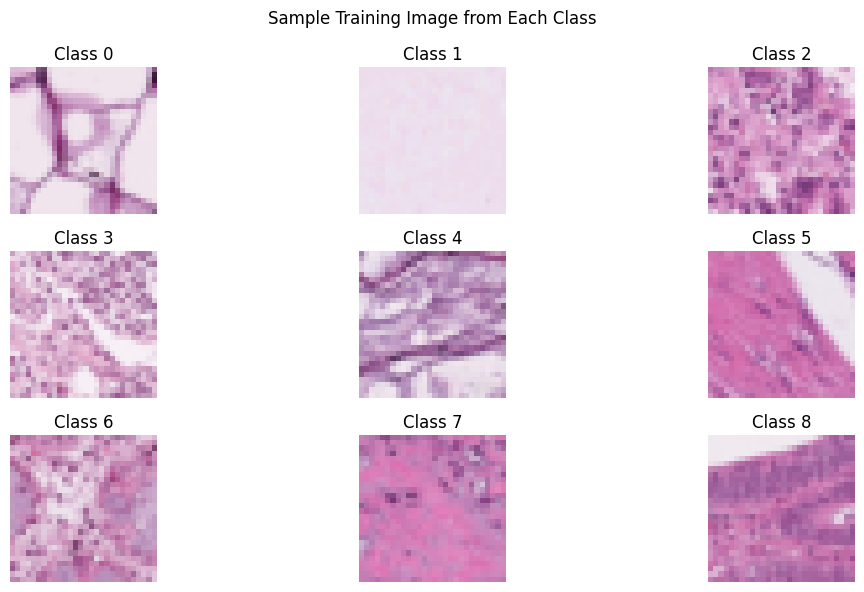

In [6]:
# Display one sample image from each class
plt.figure(figsize=(12, 6))

for i, class_label in enumerate(class_labels):
    class_indices = np.where(y_train == class_label)[0]
    sample_index = class_indices[0]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[sample_index])
    plt.title(f"Class {class_label}")
    plt.axis("off")

plt.suptitle("Sample Training Image from Each Class")
plt.tight_layout()
plt.show()

### Preprocessing

The image pixel values are normalised from the original 0–255 integer range to the 0–1 floating-point range. This helps improve numerical stability and makes the data more suitable for machine learning and neural network models.

Two versions of the image data are prepared:

1. A flattened version for traditional machine learning models and MLP models.
2. An image-shaped version for CNN models, preserving the 28×28×3 spatial structure.

In [7]:
# Normalise image pixel values from 0-255 to 0-1
X_train_normalised = X_train.astype("float32") / 255.0
X_test_normalised = X_test.astype("float32") / 255.0

# Flatten image data for traditional ML models and MLP models
X_train_flat = X_train_normalised.reshape(X_train_normalised.shape[0], -1)
X_test_flat = X_test_normalised.reshape(X_test_normalised.shape[0], -1)

# Keep image-shaped data for CNN models
X_train_cnn = X_train_normalised
X_test_cnn = X_test_normalised

print("Preprocessing completed successfully.")
print("X_train_normalised shape:", X_train_normalised.shape)
print("X_train_flat shape:", X_train_flat.shape)
print("X_train_cnn shape:", X_train_cnn.shape)

print("\nNormalised training pixel range:")
print("Minimum:", X_train_normalised.min())
print("Maximum:", X_train_normalised.max())

Preprocessing completed successfully.
X_train_normalised shape: (32000, 28, 28, 3)
X_train_flat shape: (32000, 2352)
X_train_cnn shape: (32000, 28, 28, 3)

Normalised training pixel range:
Minimum: 0.0
Maximum: 1.0


### Examples of preprocessed data

This step displays examples of the normalised image data after preprocessing. Since normalisation only rescales pixel values and does not change the visual structure of the images, the images should look visually similar to the original samples while having pixel values in the 0–1 range.

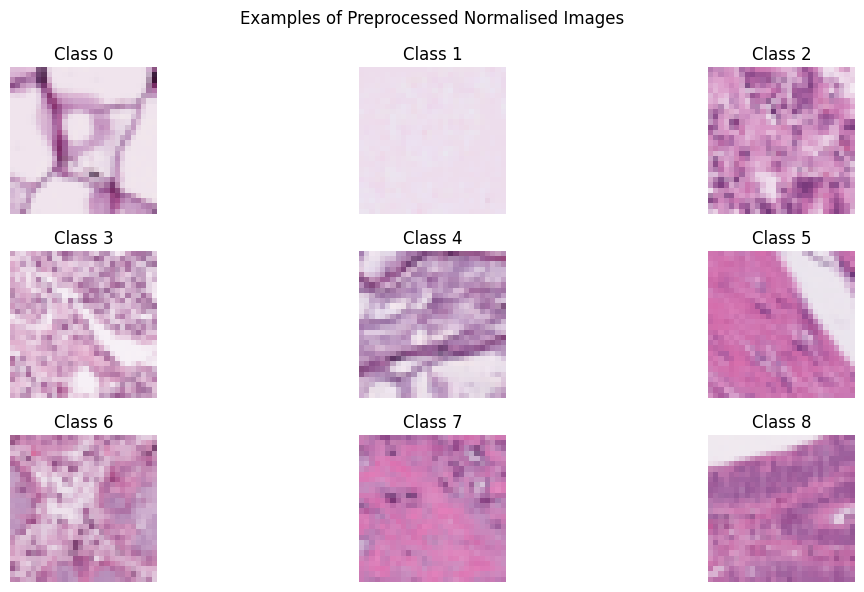

Preprocessed pixel value range:
Minimum: 0.0
Maximum: 1.0


In [8]:
# Display examples of preprocessed normalised images
plt.figure(figsize=(12, 6))

for i, class_label in enumerate(class_labels):
    class_indices = np.where(y_train == class_label)[0]
    sample_index = class_indices[0]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train_normalised[sample_index])
    plt.title(f"Class {class_label}")
    plt.axis("off")

plt.suptitle("Examples of Preprocessed Normalised Images")
plt.tight_layout()
plt.show()

print("Preprocessed pixel value range:")
print("Minimum:", X_train_normalised.min())
print("Maximum:", X_train_normalised.max())

#### Train/validation split for baseline models

The original training data is split into a training subset and a validation subset. The validation subset is used to check model performance before hyperparameter tuning and final test evaluation. Stratification is used so that the class proportions are preserved in both splits.

In [9]:
# Create a validation split from the training data for baseline model development
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train_flat,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Baseline model training/validation split created successfully.")
print("X_train_base shape:", X_train_base.shape)
print("X_val_base shape:", X_val_base.shape)
print("y_train_base shape:", y_train_base.shape)
print("y_val_base shape:", y_val_base.shape)

Baseline model training/validation split created successfully.
X_train_base shape: (25600, 2352)
X_val_base shape: (6400, 2352)
y_train_base shape: (25600,)
y_val_base shape: (6400,)


## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course
#### Initial Random Forest baseline

Random Forest is used as the traditional machine learning baseline. It is an ensemble method based on multiple decision trees and can model non-linear relationships between input features. This makes it more suitable than a purely linear baseline for image data represented as flattened pixel features.

The 28×28×3 images are flattened into 2352-dimensional feature vectors before training. Although Random Forest does not directly preserve the spatial structure of images, it provides a useful non-neural baseline for comparison against the MLP and CNN models.

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train an initial Random Forest baseline model
start_time = time.time()

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_rf.fit(X_train_base, y_train_base)

baseline_rf_training_time = time.time() - start_time

# Evaluate on the validation set
y_val_pred_rf = baseline_rf.predict(X_val_base)
baseline_rf_val_accuracy = accuracy_score(y_val_base, y_val_pred_rf)

print("Initial Random Forest model trained successfully.")
print("Validation accuracy:", round(baseline_rf_val_accuracy, 4))
print("Training time (seconds):", round(baseline_rf_training_time, 2))

Initial Random Forest model trained successfully.
Validation accuracy: 0.6342
Training time (seconds): 8.32


#### Initial Random Forest validation performance

The validation performance of the initial Random Forest model is examined using a classification report. This provides class-wise precision, recall, and F1-score, which is more informative than accuracy alone, especially when the class distribution is not perfectly balanced.

In [11]:
# Display class-wise validation performance for the initial Random Forest model
print("Initial Random Forest Classification Report:")
print(classification_report(y_val_base, y_val_pred_rf))

Initial Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       698
           1       0.99      0.87      0.92       686
           2       0.58      0.30      0.40       701
           3       0.72      0.73      0.72       731
           4       0.53      0.64      0.58       590
           5       0.61      0.71      0.65       858
           6       0.46      0.11      0.18       546
           7       0.50      0.47      0.49       651
           8       0.49      0.73      0.58       939

    accuracy                           0.63      6400
   macro avg       0.63      0.61      0.60      6400
weighted avg       0.63      0.63      0.61      6400



#### Initial Random Forest confusion matrix

A confusion matrix is used to inspect which classes are being confused by the initial Random Forest model. This helps identify whether the model performs poorly across all classes or mainly struggles with specific tissue categories.

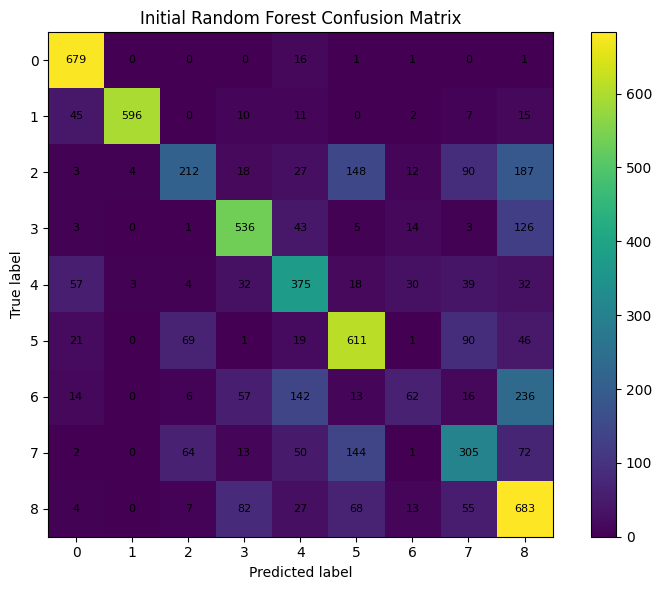

In [12]:
# Compute and display confusion matrix for the initial Random Forest model
rf_conf_matrix = confusion_matrix(y_val_base, y_val_pred_rf)

plt.figure(figsize=(8, 6))
plt.imshow(rf_conf_matrix)
plt.title("Initial Random Forest Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

plt.xticks(class_labels)
plt.yticks(class_labels)

for i in range(rf_conf_matrix.shape[0]):
    for j in range(rf_conf_matrix.shape[1]):
        plt.text(j, i, rf_conf_matrix[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### Fully connected neural network
#### Initial fully connected neural network / MLP

A fully connected neural network, also known as a multilayer perceptron (MLP), is used as the second classifier. The MLP takes the flattened 2352-dimensional image vectors as input and learns non-linear relationships using dense hidden layers and activation functions.

Unlike Random Forest, the MLP is trained using gradient-based optimisation. However, because the image is flattened, the MLP does not directly preserve the spatial structure of the 28×28 image. This makes it a useful comparison point between the traditional Random Forest baseline and the CNN model, which is designed to use spatial image patterns.

In [13]:
# Build an initial MLP model
mlp_model = keras.Sequential([
    layers.Input(shape=(X_train_flat.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_labels), activation="softmax")
])

mlp_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 310,025 (1.18 MB)

 Trainable params: 310,025 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

#### Initial MLP training

The initial MLP model is trained using the flattened normalised image data. A validation set is used to monitor performance before formal hyperparameter tuning. This initial run checks that the MLP architecture is functional and provides a baseline neural network result.

In [14]:
# Train the initial MLP model
start_time = time.time()

mlp_history = mlp_model.fit(
    X_train_base,
    y_train_base,
    validation_data=(X_val_base, y_val_base),
    epochs=10,
    batch_size=64,
    verbose=1
)

mlp_training_time = time.time() - start_time

# Evaluate initial MLP on validation set
mlp_val_loss, mlp_val_accuracy = mlp_model.evaluate(X_val_base, y_val_base, verbose=0)

print("Initial MLP model trained successfully.")
print("Validation accuracy:", round(mlp_val_accuracy, 4))
print("Training time (seconds):", round(mlp_training_time, 2))

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2663 - loss: 1.9027 - val_accuracy: 0.3394 - val_loss: 1.7245
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3693 - loss: 1.6621 - val_accuracy: 0.3787 - val_loss: 1.5956
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4025 - loss: 1.5763 - val_accuracy: 0.4216 - val_loss: 1.5138
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4452 - loss: 1.4851 - val_accuracy: 0.4506 - val_loss: 1.4482
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4724 - loss: 1.4135 - val_accuracy: 0.4864 - val_loss: 1.3627
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4826 - loss: 1.3878 - val_accuracy: 0.4908 - val_loss: 1.3395
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4895 - loss: 1.3630 - val_accuracy: 0.5027 - val_loss: 1.3259
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4968 - loss: 1.3435 - val_accuracy: 0.

### Convolutional neural network
#### Initial convolutional neural network / CNN

A convolutional neural network (CNN) is used as the third classifier. Unlike the Random Forest and MLP models, the CNN uses the original 28×28×3 image structure instead of flattened feature vectors.

The CNN applies convolutional filters to learn local spatial patterns such as edges, textures, and tissue structures. This makes it more suitable for image classification tasks where nearby pixels contain meaningful relationships.

In [15]:
# Build an initial CNN model
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 3)),
    
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_labels), activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,441 (478.29 KB)

 Trainable params: 122,441 (478.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Initial CNN training

The initial CNN model is trained using the normalised image-shaped data. Unlike the Random Forest and MLP models, the CNN uses the 28×28×3 image structure directly. A validation set is used to monitor performance before formal hyperparameter tuning.

In [16]:
# Create image-shaped training and validation splits for CNN
X_train_cnn_base, X_val_cnn_base, y_train_cnn_base, y_val_cnn_base = train_test_split(
    X_train_cnn,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("CNN training/validation split created successfully.")
print("X_train_cnn_base shape:", X_train_cnn_base.shape)
print("X_val_cnn_base shape:", X_val_cnn_base.shape)

# Train the initial CNN model
start_time = time.time()

cnn_history = cnn_model.fit(
    X_train_cnn_base,
    y_train_cnn_base,
    validation_data=(X_val_cnn_base, y_val_cnn_base),
    epochs=10,
    batch_size=64,
    verbose=1
)

cnn_training_time = time.time() - start_time

# Evaluate initial CNN on validation set
cnn_val_loss, cnn_val_accuracy = cnn_model.evaluate(X_val_cnn_base, y_val_cnn_base, verbose=0)

print("Initial CNN model trained successfully.")
print("Validation accuracy:", round(cnn_val_accuracy, 4))
print("Training time (seconds):", round(cnn_training_time, 2))

CNN training/validation split created successfully.
X_train_cnn_base shape: (25600, 28, 28, 3)
X_val_cnn_base shape: (6400, 28, 28, 3)
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4213 - loss: 1.5392 - val_accuracy: 0.5441 - val_loss: 1.2384
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6009 - loss: 1.0704 - val_accuracy: 0.6392 - val_loss: 0.9763
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6601 - loss: 0.9344 - val_accuracy: 0.6669 - val_loss: 0.8990
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6868 - loss: 0.8602 - val_accuracy: 0.6986 - val_loss: 0.8202
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7059 - loss: 0.8101 - val_accuracy: 0.7083 - val_loss: 0.8029
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7214 - loss: 0.7645 - val_accuracy: 0.7058 - val_loss: 0.8109
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7349 - loss: 0.7292 - val_accu

#### Initial model comparison before hyperparameter tuning

The initial CNN achieved the strongest validation accuracy among the three untuned models. This is expected because the CNN preserves and learns from the spatial structure of the images, while the Random Forest and MLP use flattened image vectors. The Random Forest performed better than the initial MLP, likely because it can capture some non-linear relationships between pixel features without requiring gradient-based training.

These initial results provide a baseline before formal hyperparameter tuning is performed in the next section.

## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Algorithm of choice from first six weeks of course

### Fully connected neural network

### Convolutional neural network

## 5. AI Acknowledgement
Include acknowledgement of AI usage here. 
